**SISTEMATIZAÇÃO DE CIÊNCIA DE DADOS II**

Aluna: Thamires Gil Godoy

Dados: Top Spotify Podcast Episodes

Dados disponiveis em: https://www.kaggle.com/datasets/daniilmiheev/top-spotify-podcasts-daily-updated


*   date: data de quando os dados foram coletados
*   rank: a posição diária de um podcast entre os 200 primeiros
*   region: o código ISO do país
*   chart rank move: a variação na classificação com relação ao dia anterior
*   episodeURI: identificador único do episódio no Spotify
*   showURI: identificador único do programa no Spotify
*   episodeName: Nome do episódio
*   description: Descrição do episódio. Alguns episódios não possuem.
*   show.name: Nome do programa
*   show.publisher: Descrição do programa
*   duration_ms: duração do episodio em ms
*   explicit: boleano definindo se os dados são explicitos ou não
*   languages: idioma
*   release_date: data de lançamento
*   show.media_type: forma de midia diponivel (audio, video)
*   show.total_episodes: total de episodios

# 0. PREPARAÇÃO DO AMBIENTE

In [1]:
# Instalações necessárias
!pip install kaggle -q

In [2]:
# Bibliotecas necessárias
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Sistematizacao") \
    .getOrCreate()

from pyspark.sql.functions import col, sum, count, round, to_date, expr, when, avg, first, date_format, datediff
from pyspark.sql.window import Window
from collections import Counter
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator



# 1. INGESTÃO E PRÉ-PROCESSAMENTO

In [3]:
# Primeiro os dados são baixados
!kaggle datasets download -d daniilmiheev/top-spotify-podcasts-daily-updated -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/daniilmiheev/top-spotify-podcasts-daily-updated
License(s): ODC Attribution License (ODC-By)
100% 645M/645M [00:07<00:00, 88.0MB/s]



In [4]:
# Em seguida, são lidos e alguns são mostrados
# Nesse ponto, a visualização de 15 ou 20 registros não mostrava um erro que foi percebido ao longo da limpeza:
# a locação de dados em colunas erradas
# com 50 isso já é verificado
df_spotify_csv = spark.read.csv ("/content/data/top_podcasts.csv",header=True)
df_spotify_csv.show(50)

# guardar a qunatidade de registros antes da limpeza
qtd_linhas_antes = df_spotify_csv.count()

+----------+----+------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------+------------+---------------+-------------------+
|      date|rank|region|chartRankMove|          episodeUri|             showUri|         episodeName|         description|           show.name|      show.publisher|         duration_ms|            explicit|       languages|release_date|show.media_type|show.total_episodes|
+----------+----+------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------+------------+---------------+-------------------+
|2024-09-02|   1|    us|    UNCHANGED|37kBZRr3nqjltQXt8...|4rOoJ6Egrf8K2Iryw...|  #2197 - Mike Baker|"Mike Baker is a ...|The Joe Rogan Exp...|           Joe Rogan|           987210

In [5]:
# Para melhorar o entendimento e para que não ocorra erro devido a nomes com ponto, as colunas são renomeadas

df_spotify_csv = df_spotify_csv.withColumnRenamed("date", "data")
df_spotify_csv = df_spotify_csv.withColumnRenamed("rank", "posicao")
df_spotify_csv = df_spotify_csv.withColumnRenamed("region", "pais")
df_spotify_csv = df_spotify_csv.withColumnRenamed("chartRankMove", "var_classifica")
df_spotify_csv = df_spotify_csv.withColumnRenamed("episodeUri", "id_episodio")
df_spotify_csv = df_spotify_csv.withColumnRenamed("showUri", "id_programa")
df_spotify_csv = df_spotify_csv.withColumnRenamed("episodeName", "nome_episodio")
df_spotify_csv = df_spotify_csv.withColumnRenamed("description", "descricao")
df_spotify_csv = df_spotify_csv.withColumnRenamed("show.name", "nome_programa")
df_spotify_csv = df_spotify_csv.withColumnRenamed("show.publisher", "editora")
df_spotify_csv = df_spotify_csv.withColumnRenamed("duration_ms", "duracao_ms")
df_spotify_csv = df_spotify_csv.withColumnRenamed("explicit", "explicito")
df_spotify_csv = df_spotify_csv.withColumnRenamed("languages", "idioma")
df_spotify_csv = df_spotify_csv.withColumnRenamed("release_date", "data_lancamento")
df_spotify_csv = df_spotify_csv.withColumnRenamed("show.media_type", "forma_midia")
df_spotify_csv = df_spotify_csv.withColumnRenamed("show.total_episodes", "epis_totais")

df_spotify_csv.show(8)

+----------+-------+----+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+---------+---------+---------------+-----------+-----------+
|      data|posicao|pais|var_classifica|         id_episodio|         id_programa|       nome_episodio|           descricao|       nome_programa|             editora|duracao_ms|explicito|   idioma|data_lancamento|forma_midia|epis_totais|
+----------+-------+----+--------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+---------+---------+---------------+-----------+-----------+
|2024-09-02|      1|  us|     UNCHANGED|37kBZRr3nqjltQXt8...|4rOoJ6Egrf8K2Iryw...|  #2197 - Mike Baker|"Mike Baker is a ...|The Joe Rogan Exp...|           Joe Rogan| 9872105.0|     True|   ['en']|     2024-08-29|      mixed|     2366.0|
|2024-09-02|      2|  us|     UNCHANGED|293KKxbE

In [6]:
# Para esse trabalho algumas colunas não serão usadas, por isso serão excluidas

df_spotify_csv = df_spotify_csv.drop("id_episodio", "id_programa")
df_spotify_csv.printSchema() #e pelo shcema verifica-se que os tipos de dados não estão adequados
df_spotify_csv.show(15)


root
 |-- data: string (nullable = true)
 |-- posicao: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- var_classifica: string (nullable = true)
 |-- nome_episodio: string (nullable = true)
 |-- descricao: string (nullable = true)
 |-- nome_programa: string (nullable = true)
 |-- editora: string (nullable = true)
 |-- duracao_ms: string (nullable = true)
 |-- explicito: string (nullable = true)
 |-- idioma: string (nullable = true)
 |-- data_lancamento: string (nullable = true)
 |-- forma_midia: string (nullable = true)
 |-- epis_totais: string (nullable = true)

+----------+-------+----+--------------+--------------------+--------------------+--------------------+--------------------+----------+---------+---------+---------------+-----------+-----------+
|      data|posicao|pais|var_classifica|       nome_episodio|           descricao|       nome_programa|             editora|duracao_ms|explicito|   idioma|data_lancamento|forma_midia|epis_totais|
+----------+-------+-

In [7]:
# O próximo passo foi analisar a porcentagem de nulos que existem

#total de linhas
t_linhas = df_spotify_csv.count()

#porcentagem de nulos por coluna
porc_nulos = df_spotify_csv.select([
    (sum(col(c).isNull().cast("int")) / t_linhas).alias(c)
    for c in df_spotify_csv.columns
])

porc_nulos.show()


# O resultado mostra que a coluna descricao é a que possui maior porcentagem de nulos (0,00873%), mas nenhuma coluna chega a 1%
# Aparentemente os valores nulos parecem não possuir grande influencia no conjunto de dados,
# no entanto, verificou-se que certas colunas resultaram em valores similares e assim, a análise dos valores nulos seguiu

+----+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|data|             posicao|                pais|      var_classifica|       nome_episodio|          descricao|       nome_programa|             editora|          duracao_ms|           explicito|              idioma|     data_lancamento|         forma_midia|         epis_totais|
+----+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
| 0.0|1.161758117603322E-5|1.161758117603322E-5|1.161758117603322E-5|1.161758117603322E-5|0.00873206445143597|1.909639905810460...|2.127469552861083...|1.967727811

In [8]:
# Pelo resultado anterior, temos que a porcentagem de dados nulos em posicao, pais, var_classifica e nome_episodio é a mesma
# Dessa forma, questinou-se se o registro que é nulo em uma dessas colunas também está nulo nas outras
# Assim, contou-se a quantidade de registros nulos ao mesmo tempo nessas quatro colunas e obteve-se a porcetagem com relação ao total

# Linhas onde todas as colunas especificadas são nulas
linhas_nulas = df_spotify_csv.filter(
    col("posicao").isNull() &
    col("pais").isNull() &
    col("var_classifica").isNull() &
    col("nome_episodio").isNull()
)

# Porcetagem de registros nulos nas quatro colunas ao mesmo tempo
qtd_nulas = linhas_nulas.count()
porc_nulos_comuns = qtd_nulas/t_linhas
print(qtd_nulas)
print(porc_nulos_comuns)

# Assim descobrimos que todos os registros nulos em uma dessas colunas também está nulo nas outras 3, portanto, esses 16 registros foram excluidos
df_spotify_trat = df_spotify_csv.na.drop(subset=["posicao", "pais", "var_classifica", "nome_episodio"])

16
1.161758117603322e-05


In [9]:
# O tratamento dos outros valores nulos será o seguinte:
# descricao: preencher com "nao informado"
# nome_programa: preencher com "nao informado"
# editora: preencher com "nao informado"
# duracao_ms: colocar a media dos outros registros do mesmo programa
# explicito: excluir registros nulos
# idioma: copiar de outro registro do mesmo programa (quando disponível)
# data_lancamento: excluir registros nulos
# forma_midia: excluir registros nulos
# epis_totais: copiar de outro registro do mesmo programa (quando disponível)


df_spotify_trat = df_spotify_trat.filter(
    col("explicito").isNotNull() &
    col("data_lancamento").isNotNull() &
    col("forma_midia").isNotNull())

df_spotify_trat = df_spotify_trat.fillna({
    "descricao": "nao informado",
    "nome_programa": "nao informado",
    "editora": "nao informado"})


In [10]:
# A partir daqui o tratamento de valores nulos é pausado, pois tratar duracao_ms,
# idioma e epis totais gerara erros com os registros embaralhados

# A verificação de registros duplicados (escritos de forma diferentes) será realizada para as colunas:
# pais, nome_programa e idiomas

# Para pais:
df_spotify_trat.select("pais").distinct().show(200, truncate=False)
#Como verificado, todos os códigos dos países estão corretos, não demonstrando nenhum erro de incompatibilidade a ISO

+----+
|pais|
+----+
|us  |
|cl  |
|jp  |
|pl  |
|in  |
|au  |
|gb  |
|co  |
|de  |
|br  |
|es  |
|it  |
|ar  |
|ph  |
|nl  |
|ca  |
|nz  |
|at  |
|mx  |
|fr  |
|ie  |
|id  |
+----+



In [11]:
# Para idioma

df_spotify_trat.select("idioma").distinct().show(200, truncate=False)
# A partir desse ponto, se observou que desde o carregamento dos dados há registros com dados trocados
# A solução adotada: exclui-los


+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|idioma                                                                                                                

In [12]:
# Para exclui-los utilizou-se do principio que todo registro de idioma deve estar entre [ ]
df_spotify_trat = df_spotify_trat.filter(
    col("idioma").startswith("[") & col("idioma").endswith("]")
)
df_spotify_trat.select("idioma").distinct().show(1000, truncate=False)


+----------+
|idioma    |
+----------+
|['mr']    |
|['it-IT'] |
|['ca']    |
|['fr']    |
|['es-DO'] |
|['und']   |
|['pt']    |
|['ja']    |
|['it']    |
|['de-DE'] |
|['fil']   |
|['de']    |
|['ta']    |
|['pt-PT'] |
|['en']    |
|['en-CA'] |
|['es-CL'] |
|['en-PH'] |
|['de-AT'] |
|['ur']    |
|['es-MX'] |
|['es']    |
|['bn']    |
|['fr-FR'] |
|['es-EC'] |
|['tl']    |
|['hi']    |
|['ml']    |
|['nl-NL'] |
|['en-IE'] |
|['nl']    |
|['pt-BR'] |
|['es-UY'] |
|['en-NZ'] |
|['pl-PL'] |
|['es-VE'] |
|['en-IN'] |
|['ar']    |
|['es-CO'] |
|['en-AU'] |
|['ga']    |
|['es-AR'] |
|['jv']    |
|['ja-JP'] |
|['fr-CA'] |
|['id-ID'] |
|['en-GB'] |
|['gu']    |
|['hi-HI'] |
|['es-PA'] |
|['pl']    |
|['te']    |
|['es-ES'] |
|['pa']    |
|['en-US'] |
|['id']    |
|['eu-ES'] |
|['zh-CN'] |
|['fo']    |
|['nl-BE'] |
|['es-PY'] |
|['om']    |
|['af']    |
|['es-GT'] |
|['bg']    |
|['id-IN'] |
|['es-419']|
|['da']    |
|['ko']    |
|['fi']    |
|['es-PE'] |
|['kn']    |
|['bs']    |
|['ab']    |

In [13]:
df_spotify_trat.select("nome_programa").distinct().show(1000, truncate=False)
#Como verificado, os nomes dos programas aparentam não possuir erro de nomeção
# erro que havia antes de excluir os dados embaralhados


+-----------------------------------------------------------------------------------+
|nome_programa                                                                      |
+-----------------------------------------------------------------------------------+
|Lex Fridman Podcast                                                                |
|Stuff You Should Know                                                              |
|Between Two Beers Podcast                                                          |
|Just Married: The Anthea Bradshaw Mystery                                          |
|Las Damitas Histeria                                                               |
|となりの雑談                                                                       |
|Hapa英会話 Podcast                                                                 |
|Detective Vikrant                                                                  |
|Review Buku Bisnis, Keuangan, Kehidupan.                      

In [14]:
# Verificando quantos registros foram perdidos até então

qtd_linhas_depois = df_spotify_trat.count()

print("Quantidade de linhas antes da limpeza:", qtd_linhas_antes)
print("Quantidade de linhas depois da limpeza:", qtd_linhas_depois)
porc_linhas_removidas =  ((qtd_linhas_antes-qtd_linhas_depois)*100) / qtd_linhas_antes
print("Porcentagem de linhas removidas:", porc_linhas_removidas,"%")


Quantidade de linhas antes da limpeza: 1377223
Quantidade de linhas depois da limpeza: 1238021
Porcentagem de linhas removidas: 10.107440842913602 %


In [15]:
# Agora vamos tratar os nulos que faltam
# E ao verificar qual coluna ainda possui nulos, só epis_totais tem 964 registros

qtd_nulos = df_spotify_trat.select([
    (sum(col(c).isNull().cast("int"))).alias(c)
    for c in df_spotify_trat.columns
])

qtd_nulos.show()

# Então não há a necessidade de:
# duracao_ms: colocar a media dos outros registros do mesmo programa
# idioma: copiar de outro registro do mesmo programa (quando disponível)
# Mas há a necessidade de:
# epis_totais: copiar de outro registro do mesmo programa (quando disponível)

+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+
|data|posicao|pais|var_classifica|nome_episodio|descricao|nome_programa|editora|duracao_ms|explicito|idioma|data_lancamento|forma_midia|epis_totais|
+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+
|   0|      0|   0|             0|            0|        0|            0|      0|         0|        0|     0|              0|          0|        964|
+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+



In [16]:
# Primeiro, agrupar por programa
w = Window.partitionBy("nome_programa")

# Depois preencho epis_totais nulo com o primeiro valor não nulo do mesmo programa
df_spotify_trat = df_spotify_trat.withColumn(
    "epis_totais",
    when(col("epis_totais").isNull(), first("epis_totais", ignorenulls=True).over(w))
    .otherwise(col("epis_totais"))
)

In [17]:
# Verificando os nulos que ainda existem, temos só epis_totais com 1 registro nulo. Solução: excluir

qtd_nulos = df_spotify_trat.select([
    (sum(col(c).isNull().cast("int"))).alias(c)
    for c in df_spotify_trat.columns
])

qtd_nulos.show()

df_spotify_trat = df_spotify_trat.filter(col("epis_totais").isNotNull())

+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+
|data|posicao|pais|var_classifica|nome_episodio|descricao|nome_programa|editora|duracao_ms|explicito|idioma|data_lancamento|forma_midia|epis_totais|
+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+
|   0|      0|   0|             0|            0|        0|            0|      0|         0|        0|     0|              0|          0|          1|
+----+-------+----+--------------+-------------+---------+-------------+-------+----------+---------+------+---------------+-----------+-----------+



In [18]:
qtd_linhas_depois = df_spotify_trat.count()

print("Quantidade de linhas antes da limpeza:", qtd_linhas_antes)
print("Quantidade de linhas depois da limpeza:", qtd_linhas_depois)
porc_linhas_removidas =  ((qtd_linhas_antes-qtd_linhas_depois)*100) / qtd_linhas_antes
print("Porcentagem de linhas removidas:", porc_linhas_removidas,"%")


Quantidade de linhas antes da limpeza: 1377223
Quantidade de linhas depois da limpeza: 1238020
Porcentagem de linhas removidas: 10.107513452795953 %


In [19]:
# Como verificado anteriormente, os tipos de dados não estão condizente. Portanto, houve a transformação dos tipos de dados.
# data: string (nullable = true) --> date
# duracao_ms: string (nullable = true) --> float
# explicito: string (nullable = true) --> boleano
# data_lancamento: string (nullable = true) --> date
# epis_totais: string (nullable = true) --> float --> int (dessa forma não gera NULL)
df_spotify_trans = (
    df_spotify_trat
    .withColumn("data", to_date(col("data"), "yyyy-MM-dd"))
    .withColumn("duracao_ms", expr("try_cast(duracao_ms as float)"))
    .withColumn("explicito", expr("try_cast(explicito as boolean)"))
    .withColumn("data_lancamento", to_date(col("data_lancamento"), "yyyy-MM-dd"))
    .withColumn("epis_totais", expr("try_cast(epis_totais as float)"))
)
df_spotify_trans = df_spotify_trans.withColumn(
    "epis_totais", col("epis_totais").cast("int")
)


df_spotify_trans.printSchema()
df_spotify_trans.show(50)

# Ao transformar epis_totais de string para inteiro, o erro seguinte aparece:
# NumberFormatException: [CAST_INVALID_INPUT] The value '2366.0' of the type "STRING" cannot be cast to "INT" because it is malformed
# Uma solução é usar o try_cast, que coloca NULL nos dados que não puderam ser transformados
# No entanto, para esses dados não se perderem e como não há previsão de calculos para epis_total, a transformaÇão de type não foi feita

root
 |-- data: date (nullable = true)
 |-- posicao: string (nullable = true)
 |-- pais: string (nullable = true)
 |-- var_classifica: string (nullable = true)
 |-- nome_episodio: string (nullable = true)
 |-- descricao: string (nullable = false)
 |-- nome_programa: string (nullable = false)
 |-- editora: string (nullable = false)
 |-- duracao_ms: float (nullable = true)
 |-- explicito: boolean (nullable = true)
 |-- idioma: string (nullable = true)
 |-- data_lancamento: date (nullable = true)
 |-- forma_midia: string (nullable = true)
 |-- epis_totais: integer (nullable = true)

+----------+-------+----+--------------+--------------------+--------------------+--------------------+--------------------+----------+---------+------+---------------+-----------+-----------+
|      data|posicao|pais|var_classifica|       nome_episodio|           descricao|       nome_programa|             editora|duracao_ms|explicito|idioma|data_lancamento|forma_midia|epis_totais|
+----------+-------+----+--

In [20]:
# Para auxiliar na análise se criou uma nova coluna que classifica a duracao de um episodio como longo, medio ou curto
df_spotify_eng = df_spotify_trans.withColumn(
    "faixa_duracao",
    when((col("duracao_ms")/60000) < 15, "curto")
    .when((col("duracao_ms")/60000).between(15, 45), "medio")
    .otherwise("longo")
)

In [21]:
# Para auxiliar na análise também se criou uma nova coluna que contem a data só com mês e ano
df_spotify_eng = df_spotify_eng.withColumn("mes_ano", date_format(col("data"), "MM-yyyy"))
df_spotify_eng.show(15)

+----------+-------+----+--------------+--------------------+--------------------+-------------+-------------+----------+---------+------+---------------+-----------+-----------+-------------+-------+
|      data|posicao|pais|var_classifica|       nome_episodio|           descricao|nome_programa|      editora|duracao_ms|explicito|idioma|data_lancamento|forma_midia|epis_totais|faixa_duracao|mes_ano|
+----------+-------+----+--------------+--------------------+--------------------+-------------+-------------+----------+---------+------+---------------+-----------+-----------+-------------+-------+
|2025-10-30|    119|  pl|           NEW|Czy Polska Oddała...|W tym odcinku ser...| Dawid Sołtan| Dawid Sołtan| 3239658.0|    false|['pl']|     2025-10-28|      mixed|         85|        longo|10-2025|
|2025-10-31|    187|  pl|          DOWN|Czy Polska Oddała...|W tym odcinku ser...| Dawid Sołtan| Dawid Sołtan| 3239658.0|    false|['pl']|     2025-10-28|      mixed|         85|        longo|10-2

# 2. ANÁLISE EXPLORATÓRIA COM SPARK SQL


Perguntas:
1. Qual a nacionalidade do primeiro colocado a cada mês? E com que frequencia esse pais aparece?

2. Qual pais tem mais conteudo explicito?

3. Considerando o país com mais conteúdo explicito, quantos episódios foram explicitos e quantos não foram?

4. No Brasil, quantos episódios são de longa, média e curta duração?

5. Quais são os 10 idiomas predominantes na lista, considerando a quantidade de episódios em cada idioma?

In [ ]:
# Primeiro vamos obter a view
df_spotify_eng.createOrReplaceTempView("spotify")

In [ ]:
# 1. Qual a nacionalidade do primeiro colocado a cada mês? E com que frequencia esse pais aparece?
# o ROW_NUMBER cria uma numeraçao para cada linha dentro de cada mes, onde depois selecionamos só o primeiro (rn=1)

perg1 = spark.sql("""
SELECT mes_ano, pais
FROM (
    SELECT mes_ano, pais,
           ROW_NUMBER() OVER (PARTITION BY mes_ano ORDER BY posicao ASC) AS rn
    FROM spotify
) t
WHERE rn = 1
ORDER BY mes_ano
""")

perg1.show()

+-------+----+
|mes_ano|pais|
+-------+----+
|01-2026|  co|
|02-2026|  co|
|03-2026|  co|
|04-2026|  ph|
|05-2026|  ar|
|06-2026|  ar|
|07-2026|  ar|
|09-2024|  es|
|10-2024|  id|
|10-2025|  co|
|11-2025|  co|
|12-2025|  co|
+-------+----+



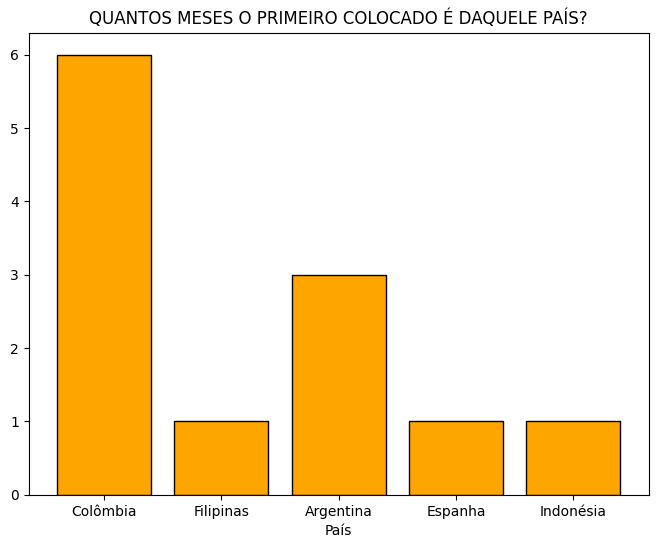

In [ ]:
results1 = perg1.collect() # essa coleta transforma o resultado da consulta em uma lista de linhas

top1_paises = Counter([row["pais"] for row in results1]) #pega o valor da coluna pais de cada linha e conta quantas vezes cada país aparece

dic_paises = {
    "co": "Colômbia",
    "ph": "Filipinas",
    "ar": "Argentina",
    "es": "Espanha",
    "id": "Indonésia"
}
paises = [dic_paises[x] for x in top1_paises.keys()] #necessario pq o results tem 12 registros e o count só 5
freq = list(top1_paises.values())


# CriaÇão do histograma
plt.figure(figsize=(8,6))
plt.bar(paises, freq, color="orange", edgecolor="black")
plt.xlabel("País")
plt.title("QUANTOS MESES O PRIMEIRO COLOCADO É DAQUELE PAÍS?")
plt.show()

+----+-------------+
|pais|qtd_explicito|
+----+-------------+
|  gb|        19039|
+----+-------------+



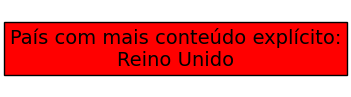

In [ ]:
#2. Qual pais tem mais conteudo explicito?

perg2 = spark.sql("""
  SELECT pais, COUNT(*) AS qtd_explicito
  FROM spotify
    WHERE explicito = true
    GROUP BY pais
ORDER BY qtd_explicito DESC
LIMIT 1
""")

perg2.show()

result2 = "Reino Unido" #como gb é Reino Unido, renomeamos o resultado para plotar

plt.figure(figsize=(2,1))
plt.axis("off")
plt.text(0.5, 0.5, f"País com mais conteúdo explícito:\n{result2}",
         ha="center", va="center", fontsize=14, bbox=dict(facecolor="red", edgecolor="black"))
plt.show()

+-----------------+-----------------+
|    pct_explicito|pct_nao_explicito|
+-----------------+-----------------+
|33.12628318892021|66.87371681107979|
+-----------------+-----------------+



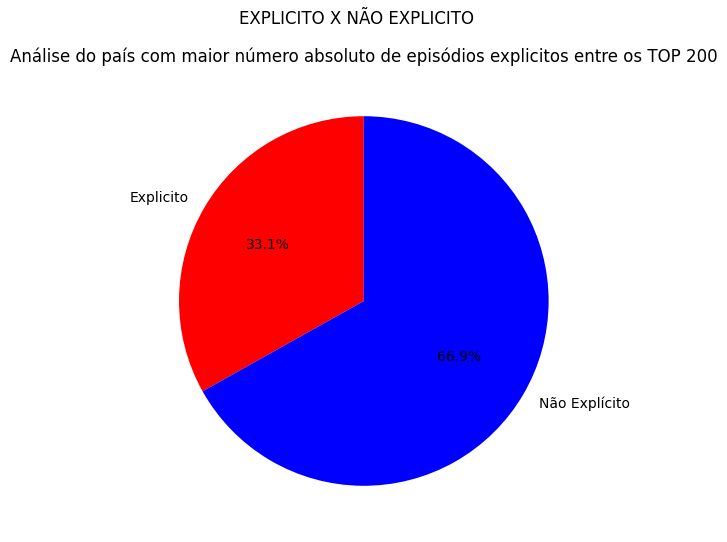

In [ ]:
# 3. Considerando o país com mais conteúdo explicito, quantos episódios foram explicitos e quantos não foram?

perg3 = spark.sql("""
SELECT
    SUM(CASE WHEN explicito = true THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct_explicito,
    SUM(CASE WHEN explicito = false THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct_nao_explicito
FROM spotify
WHERE pais = 'gb'
""")

perg3.show()

results3 = perg3.collect()[0] #list indices must be integers or slices, not str

pct_explicito = results3["pct_explicito"]
pct_nao_explicito = results3["pct_nao_explicito"]

rotulos = ["Explicito", "Não Explícito"]
valores = [pct_explicito, pct_nao_explicito]

# Grafico de pizza
plt.figure(figsize=(6,6))
plt.pie(valores, labels=rotulos, autopct='%1.1f%%', startangle=90, colors=["red","blue"])
plt.title("Análise do país com maior número absoluto de episódios explicitos entre os TOP 200")
plt.suptitle("EXPLICITO X NÃO EXPLICITO")
plt.show()


In [ ]:
# 4. No Brasil, quantos episódios são de longa, média e curta duração?
# Normalizei de 0 a 100 para melhorar a interpretaÇão

perg4 = spark.sql("""
SELECT faixa_duracao,
       COUNT(*) * 100.0 / SUM(COUNT(*)) OVER() AS norm
FROM spotify
WHERE pais = 'br'
GROUP BY faixa_duracao
ORDER BY faixa_duracao
""")

perg4.show()

+-------------+-----------------+
|faixa_duracao|             norm|
+-------------+-----------------+
|        curto|24.00875613459026|
|        longo|46.95124104085019|
|        medio|29.04000282455955|
+-------------+-----------------+



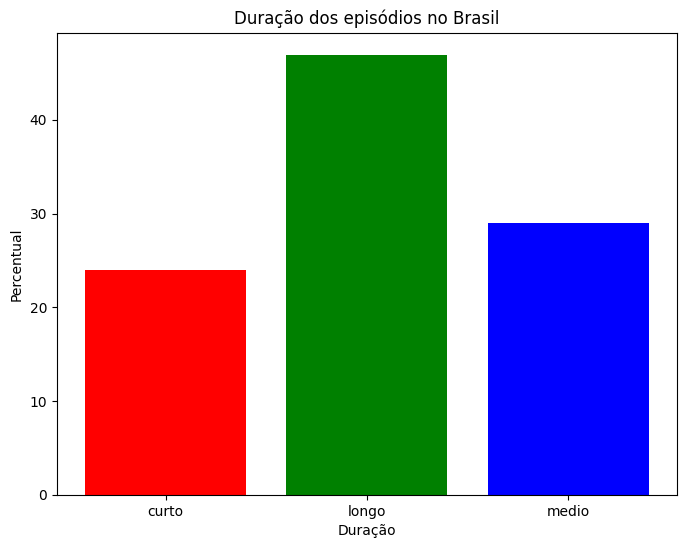

In [ ]:
results4 = perg4.collect()
categ = [row["faixa_duracao"] for row in results4]
norm = [row["norm"] for row in results4]

# Criar histograma (barras normalizadas)
plt.figure(figsize=(8,6))
plt.bar(categ, norm, color=["red","green","blue"])
plt.title("Duração dos episódios no Brasil")
plt.xlabel("Duração")
plt.ylabel("Percentual")

plt.show()


In [ ]:
#5. Quais são os 10 idiomas predominantes na lista, considerando a quantidade de episódios em cada idioma?

perg5 = spark.sql("""
SELECT idioma, COUNT(*) AS qtd
  FROM spotify
  GROUP BY idioma
  ORDER BY qtd DESC
LIMIT 10
""")

perg5.show(200)

+---------+------+
|   idioma|   qtd|
+---------+------+
|   ['en']|346021|
|   ['es']|161543|
|   ['de']| 90901|
|   ['ja']| 60207|
|   ['id']| 55295|
|   ['fr']| 53149|
|   ['nl']| 51262|
|   ['pl']| 49358|
|   ['it']| 46082|
|['en-US']| 42970|
+---------+------+



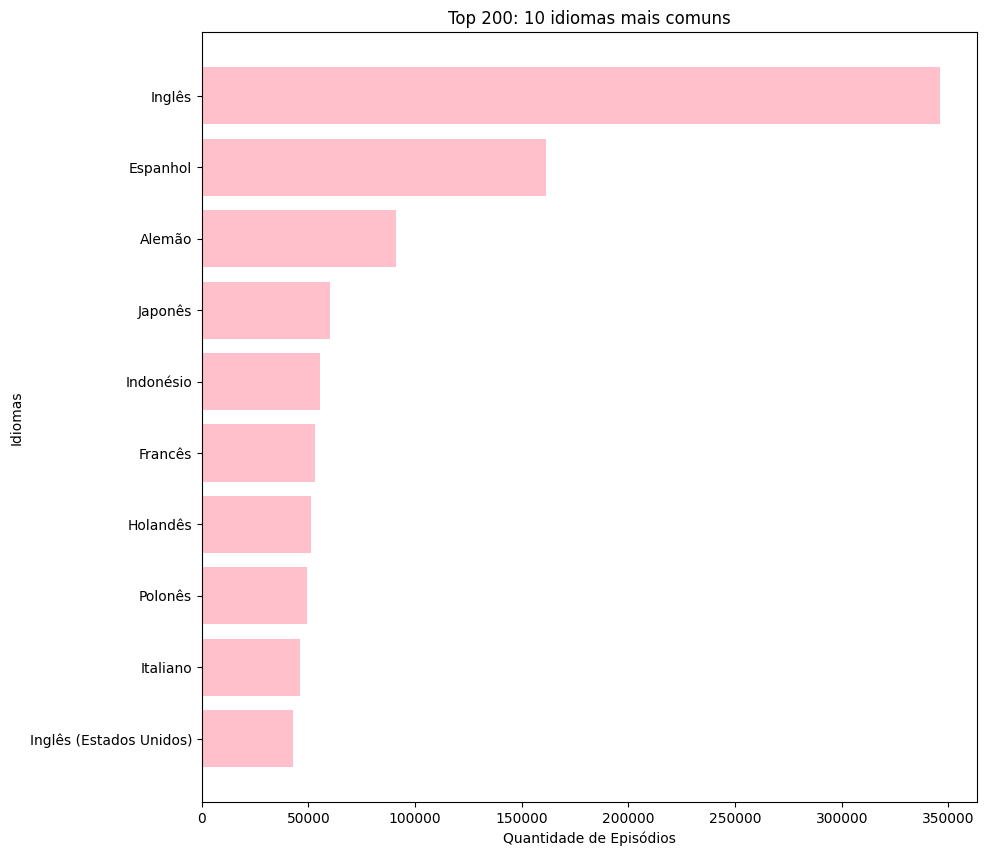

In [ ]:
results5 = perg5.collect()

dic_idiomas = {
"['en']": "Inglês",
"['es']": "Espanhol",
"['de']": "Alemão",
"['ja']": "Japonês",
"['id']": "Indonésio",
"['fr']": "Francês",
"['nl']": "Holandês",
"['pl']": "Polonês",
"['it']": "Italiano",
"['en-US']": "Inglês (Estados Unidos)"
}

idiomas = [dic_idiomas[x] for x in [row["idioma"] for row in results5]]
qtd = [row["qtd"] for row in results5]

# Grafico de barras horizontais
plt.figure(figsize=(10,10))
plt.barh(idiomas, qtd, color="pink")
plt.title("Top 200: 10 idiomas mais comuns")
plt.xlabel("Quantidade de Episódios")
plt.ylabel("Idiomas")
plt.gca().invert_yaxis()
plt.show()


# 3. MODELAGEM PREDITIVA

O objetivo dessa etapa é criar um modelo que possa estimar:
 *qual a posição diária de um episódio entre os 200 primeiros considerando os atributos: pais, nome_programa, idioma, faixa duracao e dif_tempo?*

Y = posicao: variavel categorica ordinal

X1 = pais: variavel categorica nominal

X2 = nome_programa: variavel categorica nominal

X3 = idioma: variavel categorica nominal

X4 = faixa duracao: variavel categorica ordinal

X5 = dif_tempo: variavel numerica discreta

Essa etapa aplica dois modelos preditivos para resolver o problema de classificação:

1. Regressão Logistica (RL)
2. Random Forest (RF)

In [22]:
# Primeiro criamos uma nova variável que é a diferença de dias entre a data que ele foi ranqueado e a data de lançamento

df_spotify_eng = df_spotify_eng.withColumn("dif_tempo", datediff(col("data_lancamento"), col("data")))

In [23]:
# Depois, se converteu a coluna posicao para inteiro para permitir uma ordenaçao e facilitar a analise estatistica

df_spotify_eng = df_spotify_eng.withColumn("posicao", col("posicao").cast("int"))

In [24]:
# Agora é necessário preparar as variáveis
cat_nom = ["pais", "nome_programa", "idioma"]
cat_ord = ["faixa_duracao"]
num_dis = ["dif_tempo"] # numerica, então não preciso indexar

# Como são nominais, vamos trata-las para que dados nominais possam passar por analises estatisticas
idx_nominais = [
    StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep")
    for col in cat_nom
]
enc_nominais = [
    OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vet")
    for col in cat_nom
]

# Agora as ordinais são indexadas
idx_ordinais = [
    StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep")
    for col in cat_ord
]

# e por ultimo, o nosso Y (posicao), que também é categorico
rotulo_idx = StringIndexer(inputCol="posicao", outputCol="rotulo", handleInvalid="keep")


In [25]:
# Agora, com o VectorAssembler junta-se todas as variáveis em um unico vetor numérico

montador = VectorAssembler(
    inputCols=[col+"_vet" for col in cat_nom] + [col+"_idx" for col in cat_ord] + num_dis,
    outputCol="caracteristica"
)

In [26]:
# Assim, se divide os dados que serão usados no treinamento e os dados que irão testar o modelo

treino, teste = df_spotify_eng.randomSplit([0.6, 0.4], seed=8) # divisão 7/3 ficou um pouco pior, então deixei 8/2
# Finalizado o preparo dos dados

In [27]:
# Modelo 1: Regressão Logística

rl = LogisticRegression(featuresCol="caracteristica", labelCol="rotulo", maxIter=50)

# Pipeline com as etapas
pipeline_rl = Pipeline(stages=idx_nominais + enc_nominais + idx_ordinais + [rotulo_idx, montador, rl])

# Treinamento
rl_model = pipeline_rl.fit(treino)

# Previsoes
previ_rl = rl_model.transform(teste)

In [28]:
# Modelo 2: Random Forest

rf = RandomForestClassifier(featuresCol="caracteristica", labelCol="rotulo", numTrees=100, maxBins=300)
pipeline_rf = Pipeline(stages=idx_nominais + enc_nominais + idx_ordinais + [rotulo_idx, montador, rf])
rf_model = pipeline_rf.fit(treino)
previ_rf = rf_model.transform(teste)


In [31]:
# Uma função para avaliar os modelos

def aval_modelo(previsoes, nome_modelo="Modelo"):
    aval_acuracia = MulticlassClassificationEvaluator(
        labelCol="rotulo", predictionCol="prediction", metricName="accuracy")
    aval_f1 = MulticlassClassificationEvaluator(
        labelCol="rotulo", predictionCol="prediction", metricName="f1")
    aval_preci = MulticlassClassificationEvaluator(
        labelCol="rotulo", predictionCol="prediction", metricName="weightedPrecision")
    aval_recall = MulticlassClassificationEvaluator(
        labelCol="rotulo", predictionCol="prediction", metricName="weightedRecall")

    acc = aval_acuracia.evaluate(previsoes)
    f1 = aval_f1.evaluate(previsoes)
    prec = aval_preci.evaluate(previsoes)
    rec = aval_recall.evaluate(previsoes)

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia: {acc:.4f}")
    print(f"F1:       {f1:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print()

    return {"acuracia": acc, "f1": f1, "precisao": prec, "recall": rec}

In [32]:
resultados_lr = aval_modelo(previ_rl, "Regressão Logística")
resultados_rf = aval_modelo(previ_rf, "Random Forest")

=== Regressão Logística ===
Acurácia: 0.0174
F1:       0.0127
Precisão: 0.0123
Recall:   0.0174

=== Random Forest ===
Acurácia: 0.0118
F1:       0.0047
Precisão: 0.0090
Recall:   0.0118

